# No need to run the code just see the animations

## 1. See how the line changes with each iteration of gradient descent as the parameters m and b are updated.

![GD animation](./animations/animation4.gif)

## 2. Contour plot of the path of gradient descent

![contour plot](./animations/animation8.gif)

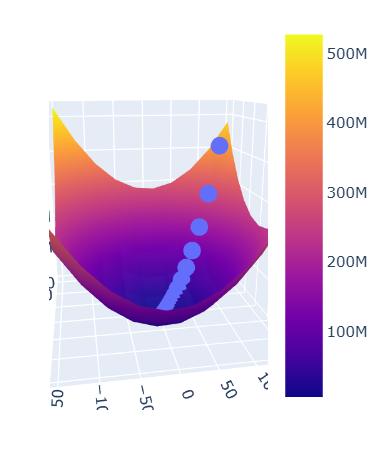
- see these are points how it is conveging to get the line of best fit.


## 3. Cost v/s epochs

![cost v/s epochs](./animations/animation5.gif)

## 4. b v/s epochs

![b v/s epochs](./animations/animation6.gif)

# 5. m v/s epochs

![m v/s epochs](./animations/animation7.gif)

# Effect of Learning Rate

- this you can go to the timestamp 1:45:00 of the video to see visualization of learning rate and how it affects the convergence of gradient descent. (optional, as we already discussed this things)

https://youtu.be/ORyfPJypKuU?si=P_Q2lAyiNN7LZN0e

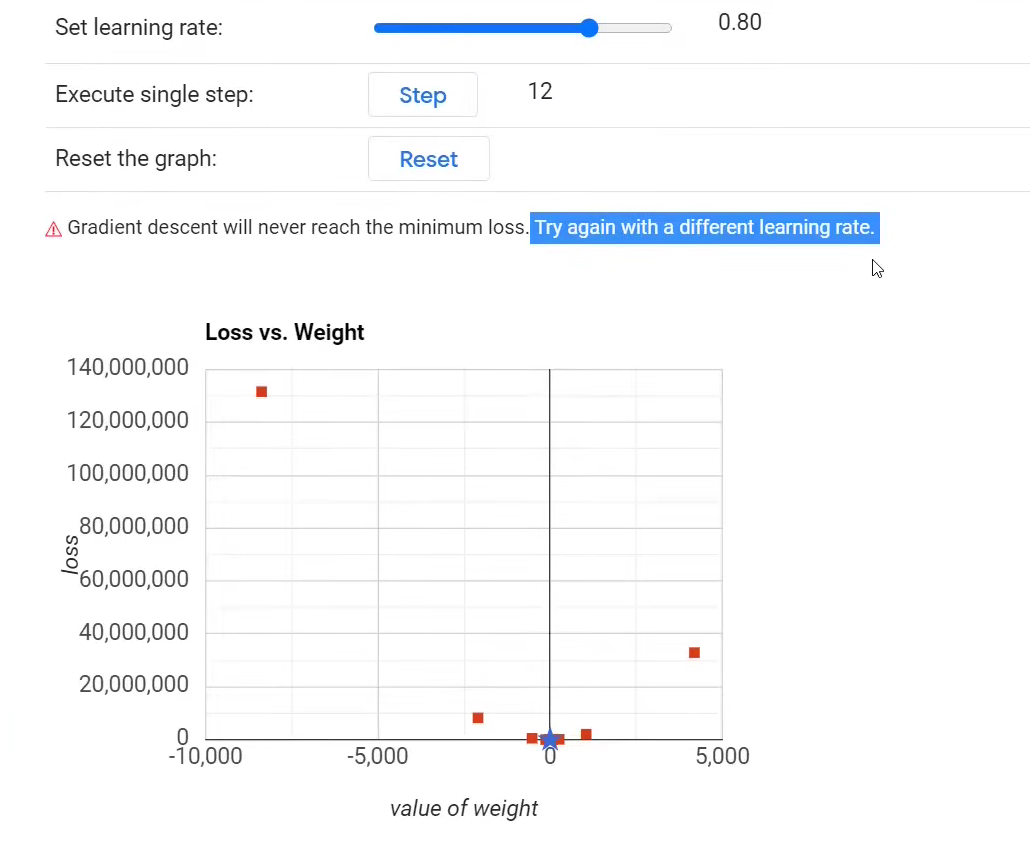

# Effect of loss function

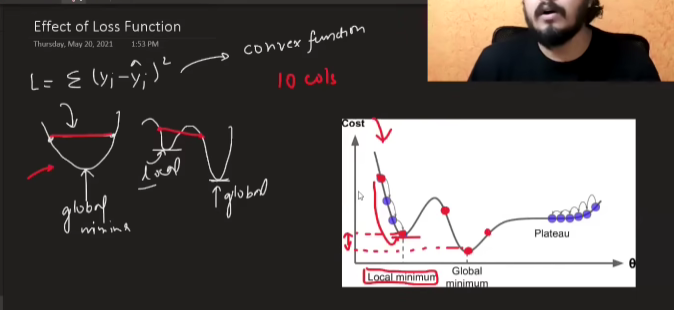

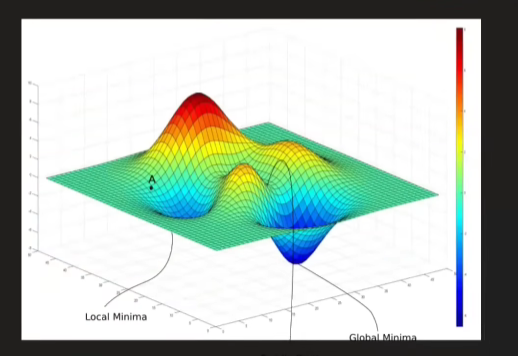

- For Linear regression the cost function was convex function (only have one minima)

- For non-convex cost functions, there can be multiple minima and gradient descent can get stuck in local minima and not reach the global minima. So initial guess matter a lot in such cases. 

- Now you might say why to take a non-convex cost function, why not always take convex cost function?

    - Because in higher dimension you dont know wether the cost function is convex or non-convex. So ur initial guess matters, maybe you can get stuck in local minima, maybe you can reach global minima

    - There are various techniques of initialization to get rid of this (We will study this in deep learning)


# Saddle point problem

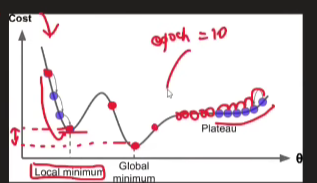

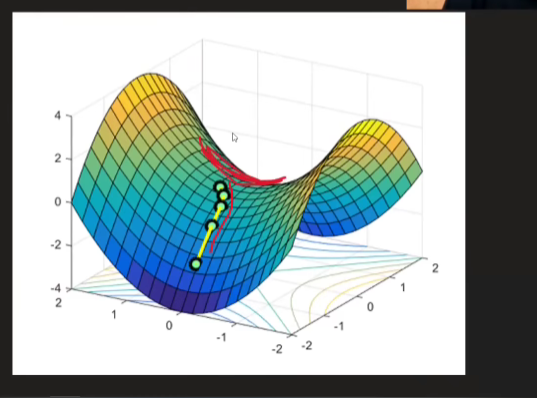

- Because of the pleatue, the gradient is very small, so the updates are very small, so it takes a lot of time to get out of the pleatue and reach the minima. So it can take a lot of time to converge.

# Effect of Data

- If the features are on different scales, then the cost function can have a very elongated shape, and gradient descent can take a lot of time to converge. So it is always better to scale the features before applying gradient descent.

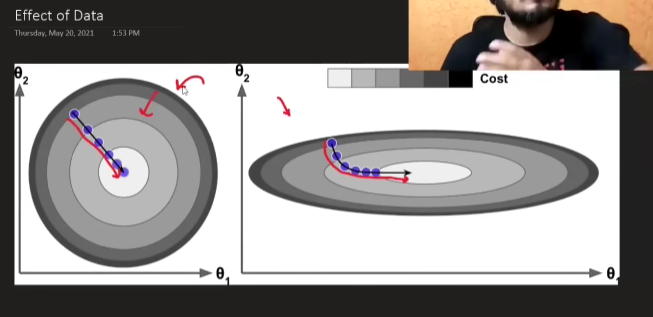



In [1]:
from sklearn.datasets import make_regression

import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [3]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

<IPython.core.display.Javascript object>


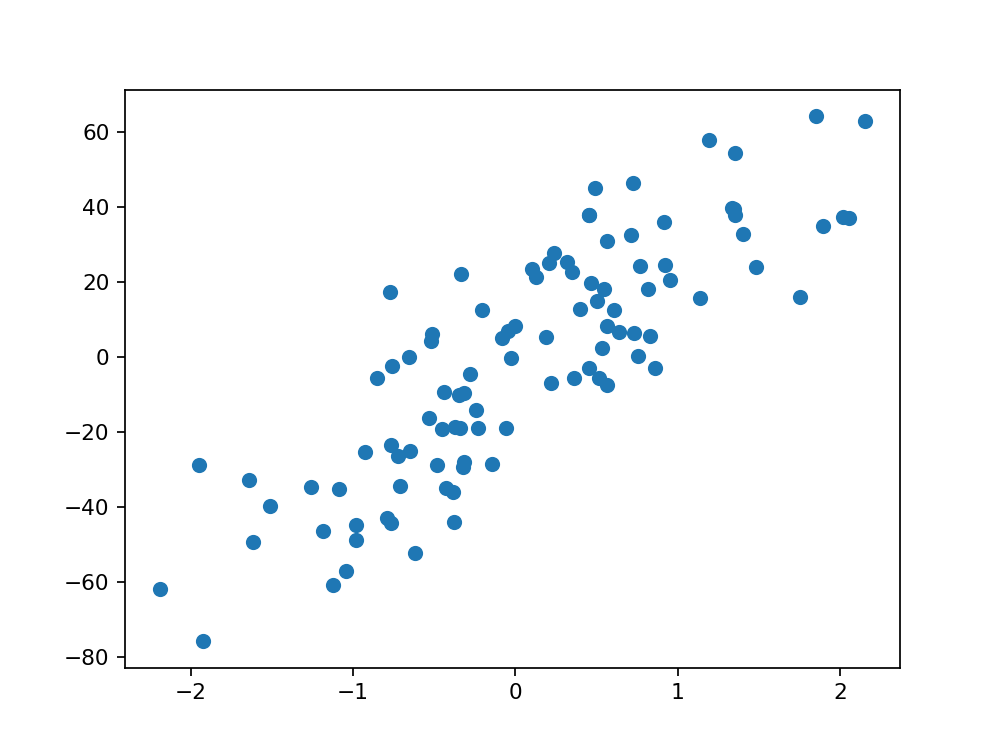

In [4]:
plt.scatter(X,y)

In [10]:
b = -520
m = 600
lr = 0.001
all_b = []
all_m = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope_b = 0
    slope_m = 0
    cost = 0
    for j in range(X.shape[0]):
        slope_b = slope_b - 2*(y[j] - (m * X[j]) -  b)
        slope_m = slope_m - 2*(y[j] - (m * X[j]) -  b)*X[j]
        cost = cost + (y[j] - m * X[j] -b) ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

<IPython.core.display.Javascript object>


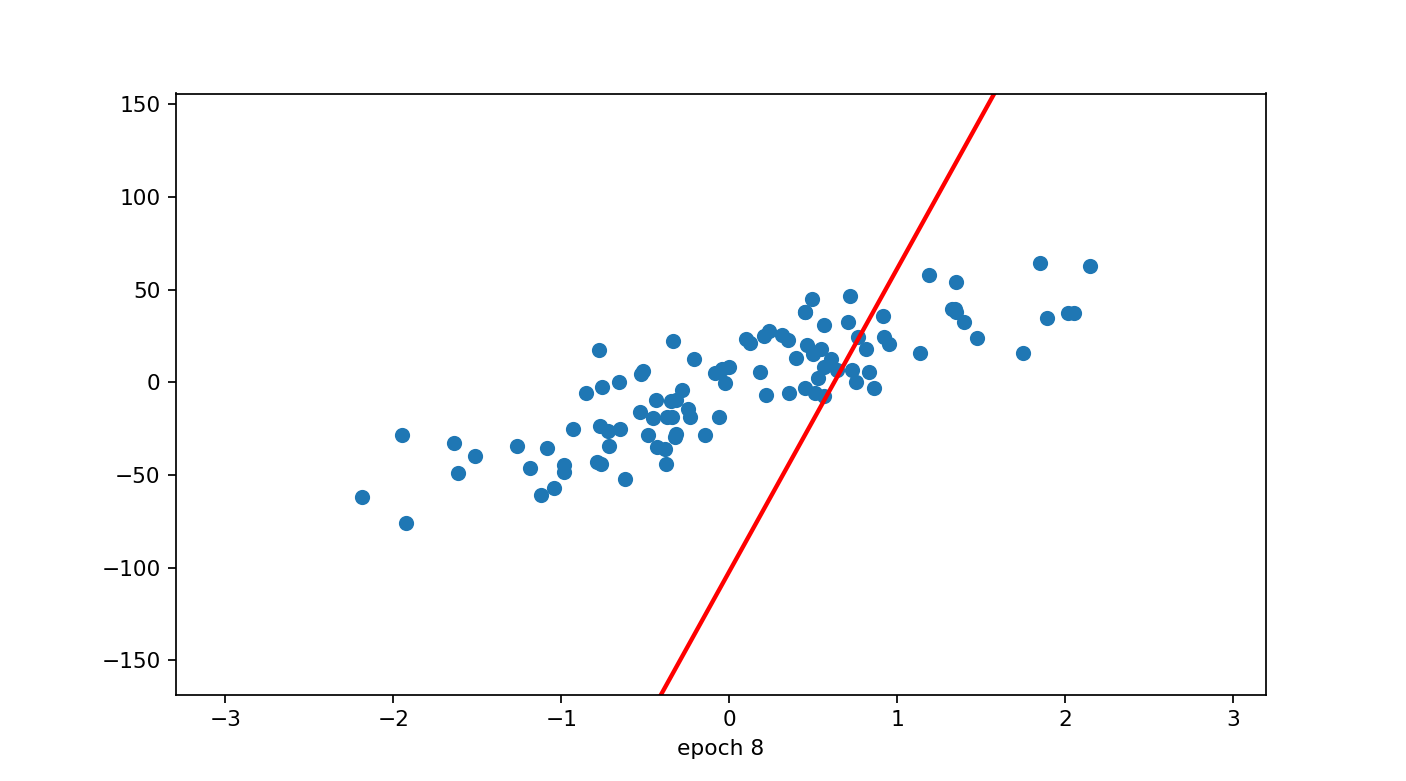

In [11]:
fig, ax = plt.subplots(figsize=(9,5))
#fig.set_tight_layout(True)

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*(-27) -150
ax.scatter(X, y)
line, = ax.plot(x_i, x_i*50 - 4, 'r-', linewidth=2)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*all_m[i] + all_b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=500)

#f = r"animation4.gif" 
#writergif = animation.PillowWriter(fps=2) 
#anim.save(f, writer=writergif)


<IPython.core.display.Javascript object>


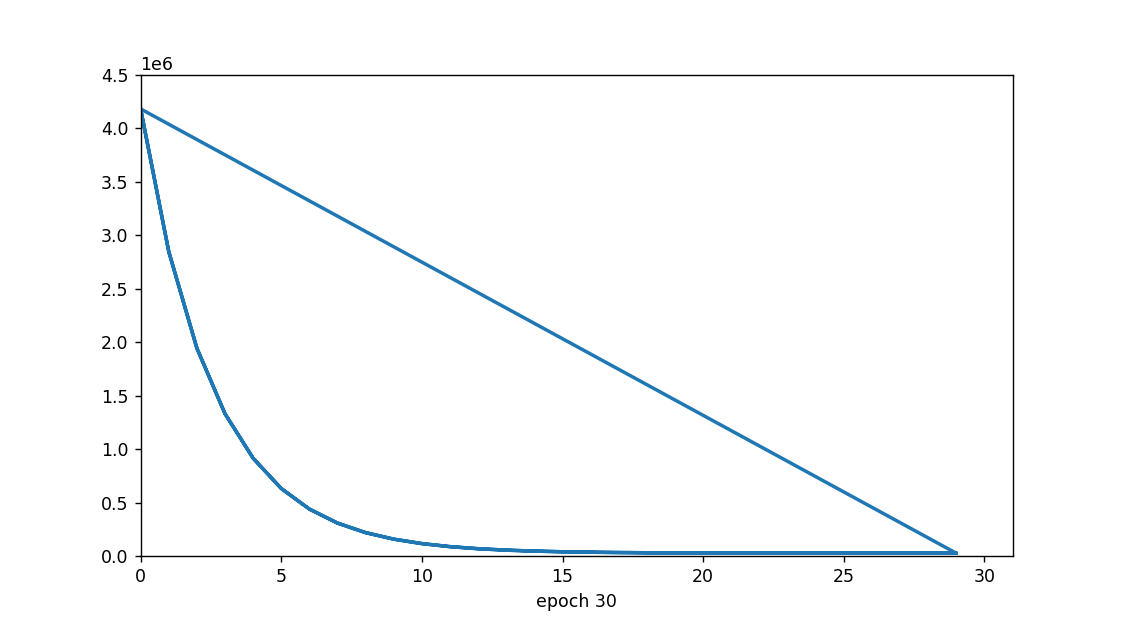

In [9]:
# Cost function
# creating a blank window 
# for the animation 
num_epochs = list(range(0,30))
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(0, 31), ylim =(0, 4500000)) 
  
line, = axis.plot([], [], lw = 2) 
  
xdata, ydata = [], [] 
  
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(num_epochs[i]) 
    ydata.append(all_cost[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation5.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)

<IPython.core.display.Javascript object>


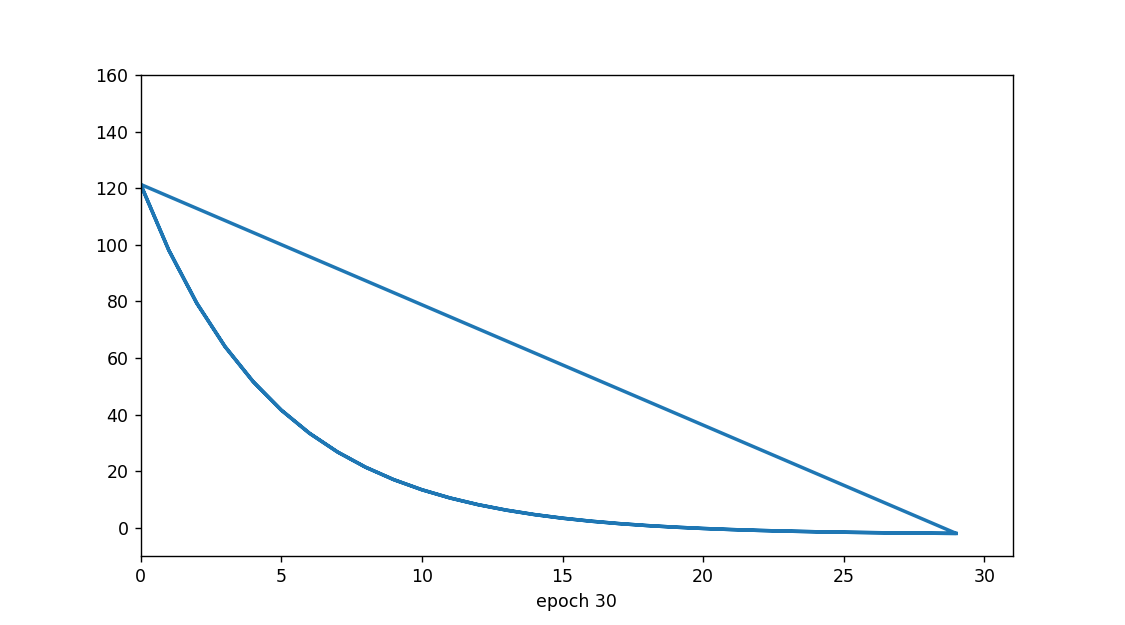

In [9]:
# intercept graph
num_epochs = list(range(0,30))
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(0, 31), ylim =(-10, 160)) 
  
line, = axis.plot([], [], lw = 2) 
  
xdata, ydata = [], [] 
  
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(num_epochs[i]) 
    ydata.append(all_b[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation6.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)

<IPython.core.display.Javascript object>


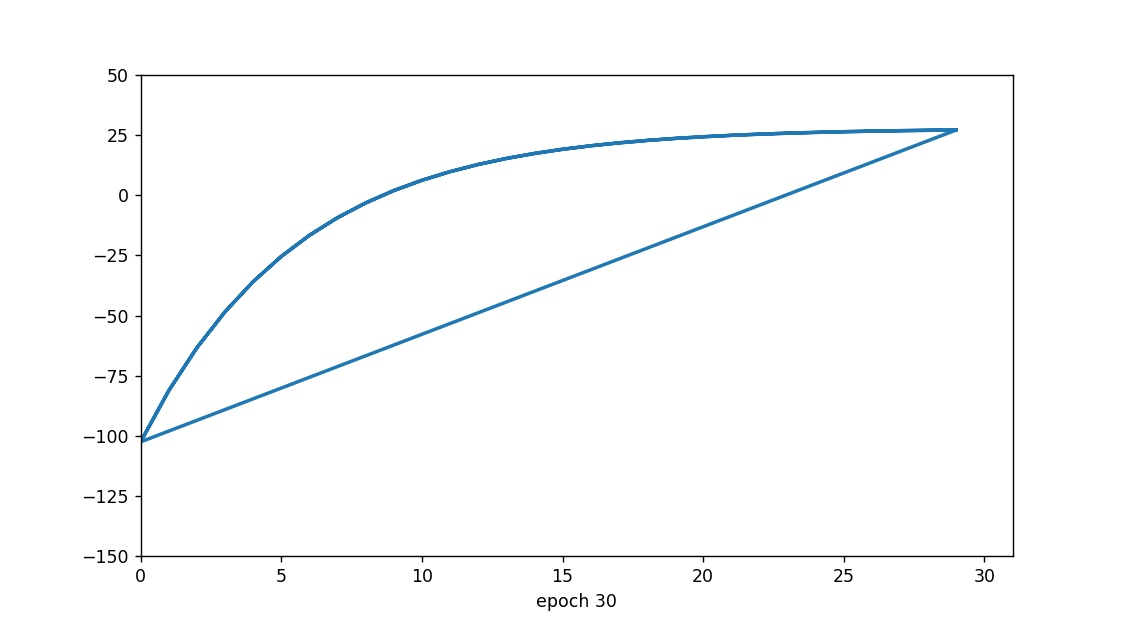

In [5]:
# intercept graph
num_epochs = list(range(0,30))
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(0, 31), ylim =(-150, 50)) 
  
line, = axis.plot([], [], lw = 2) 
  
xdata, ydata = [], [] 
  
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(num_epochs[i]) 
    ydata.append(all_m[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation7.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)